# Model_PatchTST

PatchTST was selected due to its ability to efficiently model long-range dependencies in time series data using patch-based tokenisation. Unlike traditional sequence models such as LSTM or SARIMAX, PatchTST segments the input sequence into patches, enabling the Transformer architecture to process longer contexts with reduced computational cost. This is particularly suitable for electricity demand forecasting, where both short-term and periodic patterns (e.g., weekly cycles) are important.

In [ ]:
#!git clone https://github.com/laukamkit/capstone_project_GroupA.git

In [1]:
# =========================================================
# 0. Imports
# =========================================================
import copy
import os
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import PatchTSTConfig, PatchTSTForPrediction


# =========================================================
# 1. File paths
# =========================================================
repo_path = "capstone_project_GroupA"
nsw_path = os.path.join(repo_path, "data", "NSW")

TRAIN_SCALED_PATH = os.path.join(nsw_path, "train_scaled.csv")
VAL_SCALED_PATH   = os.path.join(nsw_path, "val_scaled.csv")
TEST_SCALED_PATH  = os.path.join(nsw_path, "test_scaled.csv")
TRAIN_RAW_PATH    = os.path.join(nsw_path, "train.csv")
VAL_RAW_PATH   = os.path.join(nsw_path, "validation.csv")
TEST_RAW_PATH  = os.path.join(nsw_path, "test.csv")

# results directory
OUTPUT_DIR = os.path.join(repo_path, "output", "patchtst_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================================
# 2. Read CSV
# =========================================================
train_scaled_df = pd.read_csv(TRAIN_SCALED_PATH)
val_scaled_df   = pd.read_csv(VAL_SCALED_PATH)
test_scaled_df  = pd.read_csv(TEST_SCALED_PATH)
train_raw_df    = pd.read_csv(TRAIN_RAW_PATH)
val_raw_df    = pd.read_csv(VAL_RAW_PATH)
test_raw_df    = pd.read_csv(TEST_RAW_PATH)

print("train_scaled_df:", train_scaled_df.shape)
print("val_scaled_df  :", val_scaled_df.shape)
print("test_scaled_df :", test_scaled_df.shape)
print("train_raw_df   :", train_raw_df.shape)
print("val_raw_df  :", val_raw_df.shape)
print("test_raw_df :", test_raw_df.shape)
print("Outputs will be saved to:", OUTPUT_DIR)


# =========================================================
# 3. Recreate arrays
# =========================================================
# Demand only for PatchTST baseline
train_target_scaled = train_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)
val_target_scaled   = val_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)
test_target_scaled  = test_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)

print("train_target_scaled:", train_target_scaled.shape)
print("val_target_scaled  :", val_target_scaled.shape)
print("test_target_scaled :", test_target_scaled.shape)

# Demand and temperature for PatchTST with future temperature as input
train_temp_scaled = train_scaled_df[["TEMPERATURE"]].values.astype(np.float32)
val_temp_scaled   = val_scaled_df[["TEMPERATURE"]].values.astype(np.float32)
test_temp_scaled  = test_scaled_df[["TEMPERATURE"]].values.astype(np.float32)

print("train_temp_scaled:", train_temp_scaled.shape)
print("val_temp_scaled  :", val_temp_scaled.shape)
print("test_temp_scaled :", test_temp_scaled.shape)

# =========================================================
# 4. Rebuild target scaler from ORIGINAL unscaled training demand
# =========================================================
target_scaler = StandardScaler()
target_scaler.fit(train_raw_df[["TOTALDEMAND"]].values.astype(np.float32))

print("target mean:", target_scaler.mean_[0])
print("target std :", target_scaler.scale_[0])


# =========================================================
# 5. Device
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================================================
# 6. Helper functions
# =========================================================
def make_windows(series, context_length, prediction_length):
    """
    series: numpy array of shape (T, 1)

    Returns:
        X: (samples, context_length, 1)
        y: (samples, prediction_length, 1)
    """
    X, y = [], []
    n = len(series)

    for i in range(n - context_length - prediction_length + 1):
        past = series[i : i + context_length]
        future = series[i + context_length : i + context_length + prediction_length]

        X.append(past)
        y.append(future)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "past_values": self.X[idx],
            "future_values": self.y[idx],
        }


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        past_values = batch["past_values"].to(device)
        future_values = batch["future_values"].to(device)

        optimizer.zero_grad()
        outputs = model(
            past_values=past_values,
            future_values=future_values
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * past_values.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        past_values = batch["past_values"].to(device)
        future_values = batch["future_values"].to(device)

        outputs = model(
            past_values=past_values,
            future_values=future_values
        )
        loss = outputs.loss

        total_loss += loss.item() * past_values.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    trues = []

    for batch in loader:
        past_values = batch["past_values"].to(device)
        future_values = batch["future_values"].to(device)

        outputs = model(past_values=past_values)

        # For PatchTSTForPrediction, prediction output is usually here
        pred = outputs.prediction_outputs

        # If output shape is [batch, samples, horizon, channels], average over samples
        if pred.ndim == 4:
            pred = pred.mean(dim=1)

        preds.append(pred.cpu().numpy())
        trues.append(future_values.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    return preds, trues


def inverse_transform_3d(arr_3d, scaler):
    """
    arr_3d shape: (samples, horizon, 1)
    """
    flat = arr_3d.reshape(-1, 1)
    inv = scaler.inverse_transform(flat)
    return inv.reshape(arr_3d.shape)

c:\Users\kyim1\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: Could not import module 'PatchTSTForPrediction'. Are this object's requirements defined correctly?

## 1. PatchTST as Univariate Model

To evaluate the impact of historical input length on forecasting performance, multiple context lengths (e.g., 168, 336, 720) were tested. The context length determines how many past observations are used as input for prediction. This experiment aims to identify whether longer historical windows improve forecasting accuracy or introduce unnecessary noise.

In [67]:
import copy
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import PatchTSTConfig, PatchTSTForPrediction, set_seed
from sklearn.metrics import mean_squared_error, mean_absolute_error

def run_patchtst_experiment(
    train_series,
    val_series,
    test_series,
    target_scaler,
    context_length,
    prediction_length,
    batch_size=64,
    learning_rate=1e-3,
    epochs=20,
    patience=5,
    patch_length=16, # og patchtst paper parameter
    patch_stride=8, # og patchtst paper parameter
    d_model=128, # og patchtst paper parameter
    num_hidden_layers=3, # og patchtst paper parameter (number of encoder layers)
    num_attention_heads=16, # og patchtst paper parameter
    ffn_dim=256, # og patchtst paper parameter
    device=None,
    use_seed=None
):
    if use_seed is not None:
        set_seed(use_seed)
        print(f"Random seed set to: {use_seed}")

    # -----------------------------
    # 0. Device
    # -----------------------------
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # -----------------------------
    # 1. Create windows
    # -----------------------------
    X_train, y_train = make_windows(train_series, context_length, prediction_length)
    X_val, y_val     = make_windows(val_series, context_length, prediction_length)
    X_test, y_test   = make_windows(test_series, context_length, prediction_length)

    print(f"\nHorizon = {prediction_length}")
    print("Using device:", device)
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
    print("X_test :", X_test.shape,  "y_test :", y_test.shape)

    # -----------------------------
    # 2. Create datasets/loaders
    # -----------------------------
    train_ds = ForecastDataset(X_train, y_train)
    val_ds   = ForecastDataset(X_val, y_val)
    test_ds  = ForecastDataset(X_test, y_test)

    # time series -> shuffle=False
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # -----------------------------
    # 3. Build model
    # -----------------------------
    config = PatchTSTConfig(
        num_input_channels=1,
        context_length=context_length,
        prediction_length=prediction_length,
        patch_length=patch_length,
        patch_stride=patch_stride,
        d_model=d_model,
        num_hidden_layers=num_hidden_layers,
        num_attention_heads=num_attention_heads,
        ffn_dim=ffn_dim,
        head_dropout=0.1,
        loss="mse",
        scaling=None
    )

    model = PatchTSTForPrediction(config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    # -----------------------------
    # 4. Train with early stopping
    # -----------------------------
    best_val_loss = float("inf")
    best_state = None
    best_epoch = None
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best PatchTST model from epoch {best_epoch} with val_loss={best_val_loss:.6f}")

    # -----------------------------
    # 5. Predict on test
    # -----------------------------
    y_pred_scaled, y_true_scaled = predict(model, test_loader, device)

    # Safety: if model returns extra dimension structure
    if y_pred_scaled.ndim == 4:
        y_pred_scaled = y_pred_scaled.mean(axis=1)

    # -----------------------------
    # 6. Inverse transform
    # -----------------------------
    y_pred = inverse_transform_3d(y_pred_scaled, target_scaler)
    y_true = inverse_transform_3d(y_true_scaled, target_scaler)

    # -----------------------------
    # 7. Metrics
    # -----------------------------
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))

    horizon_rmse = []
    horizon_mae = []

    for h in range(prediction_length):
        rmse_h = np.sqrt(mean_squared_error(y_true[:, h, 0], y_pred[:, h, 0]))
        mae_h = mean_absolute_error(y_true[:, h, 0], y_pred[:, h, 0])
        horizon_rmse.append(rmse_h)
        horizon_mae.append(mae_h)

    result = {
        "model_name": "PatchTST_no_temperature",
        "prediction_length": prediction_length,
        "context_length": context_length,
        "patch_length": patch_length,
        "patch_stride": patch_stride,
        "seed": use_seed,
        "rmse": rmse,
        "mae": mae,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "n_train_windows": len(X_train),
        "n_val_windows": len(X_val),
        "n_test_windows": len(X_test)
    }

    history_df = pd.DataFrame(history)
    horizon_detail_df = pd.DataFrame({
        "step_ahead": np.arange(1, prediction_length + 1),
        "rmse": horizon_rmse,
        "mae": horizon_mae
    })

    artifacts = {
        "model": model,
        "seed": use_seed,
        "test_loader": test_loader,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred_scaled": y_pred_scaled,
        "y_true_scaled": y_true_scaled,
        "y_pred": y_pred,
        "y_true": y_true,
        "device": device,
        "context_length": context_length,
        "prediction_length": prediction_length
    }

    return result, history_df, horizon_detail_df, artifacts

In [25]:
HORIZONS = [48, 96, 192, 336, 720]

CONTEXT_LENGTHS = [336, 512]   # based on og patchtst paper (PatchTST/64 and PatchTST/42). We can do the others for ablation study.
PATCH_LENGTH = 16 # PatchTST/64 means 512 / (16 patch length - 8 strides) = 64 patches. Similarly, PatchTST/42 means 336 / (16 patch length - 8 strides) = 42 patches.
STRIDE = 8

BATCH_SIZE = 64

LEARNING_RATE = 1e-3
EPOCHS = 20
PATIENCE = 5
SEEDS = [42, 777] # for multiple runs to check stability


all_results = []
all_histories = {}
all_horizon_details = {}
all_artifacts = {}

for context_length in CONTEXT_LENGTHS:
    for horizon in HORIZONS:
        for seed in SEEDS:
            print("=" * 80)
            print(f"Running PatchTST | context_length={context_length} | horizon={horizon} | seed={seed}")

            result, history_df, horizon_detail_df, artifacts = run_patchtst_experiment(
                train_series=train_target_scaled,
                val_series=val_target_scaled,
                test_series=test_target_scaled,
                target_scaler=target_scaler,
                context_length=context_length,
                prediction_length=horizon,
                batch_size=BATCH_SIZE,
                learning_rate=LEARNING_RATE,
                epochs=EPOCHS,
                patience=PATIENCE,
                patch_length=PATCH_LENGTH,
                patch_stride=STRIDE,
                use_seed=seed,
                d_model=128, # og patchtst paper parameter
                num_hidden_layers=3, # og patchtst paper parameter (number of encoder layers)
                num_attention_heads=16, # og patchtst paper parameter
                ffn_dim=256,# og patchtst paper parameter
                device=device
            )

            all_results.append(result)

            key = f"ctx{context_length}_hor{horizon}"
            all_histories[key] = history_df
            all_horizon_details[key] = horizon_detail_df
            all_artifacts[key] = artifacts

Running PatchTST | context_length=336 | horizon=48 | seed=42
Random seed set to: 42

Horizon = 48
Using device: cuda
X_train: (53314, 336, 1) y_train: (53314, 48, 1)
X_val  : (17516, 336, 1) y_val  : (17516, 48, 1)
X_test : (17517, 336, 1) y_test : (17517, 48, 1)
Epoch 01 | train_loss=0.291753 | val_loss=0.205440
Epoch 02 | train_loss=0.152903 | val_loss=0.185368
Epoch 03 | train_loss=0.135820 | val_loss=0.199622
Epoch 04 | train_loss=0.127708 | val_loss=0.170894
Epoch 05 | train_loss=0.119249 | val_loss=0.175570
Epoch 06 | train_loss=0.112461 | val_loss=0.175196
Epoch 07 | train_loss=0.106906 | val_loss=0.169256
Epoch 08 | train_loss=0.103030 | val_loss=0.180070
Epoch 09 | train_loss=0.096434 | val_loss=0.175284
Epoch 10 | train_loss=0.092308 | val_loss=0.164269
Epoch 11 | train_loss=0.086649 | val_loss=0.187694
Epoch 12 | train_loss=0.082222 | val_loss=0.172466
Epoch 13 | train_loss=0.078802 | val_loss=0.180608
Epoch 14 | train_loss=0.076315 | val_loss=0.178283
Epoch 15 | train_loss=

In [26]:
# summary table
results_df = pd.DataFrame(all_results)

# sort for easier reading
results_df = results_df.sort_values(
    by=[ "prediction_length", "context_length"]
).reset_index(drop=True)

print("\nFinal summary:")
print(results_df)


Final summary:
                 model_name  prediction_length  context_length  patch_length  \
0   PatchTST_no_temperature                 48             336            16   
1   PatchTST_no_temperature                 48             336            16   
2   PatchTST_no_temperature                 48             512            16   
3   PatchTST_no_temperature                 48             512            16   
4   PatchTST_no_temperature                 96             336            16   
5   PatchTST_no_temperature                 96             336            16   
6   PatchTST_no_temperature                 96             512            16   
7   PatchTST_no_temperature                 96             512            16   
8   PatchTST_no_temperature                192             336            16   
9   PatchTST_no_temperature                192             336            16   
10  PatchTST_no_temperature                192             512            16   
11  PatchTST_no_temperat

The best-performing context length of 168 corresponds to one week of historical data, suggesting that electricity demand exhibits strong weekly seasonality. This indicates that the model benefits most from capturing recent cyclical patterns rather than relying on longer historical sequences. Increasing the context length beyond 168 does not improve performance and may introduce redundant or less relevant information, which can negatively impact model learning.

Forecasting errors increase as the prediction horizon extends from 48 to 720 steps, reflecting the growing uncertainty in long-term predictions.

In [27]:
def get_best_row(df, horizon):
    subset = df[df["prediction_length"] == horizon]
    return subset.loc[subset["rmse"].idxmin()]

rows = []

for h in [48, 336, 720]:
    r = get_best_row(results_df, h)
    rows.append({
        "Horizon": h,
        "Best Context Length": int(r["context_length"]),
        "n-step RMSE": r["rmse"],
        "n-step MAE": r["mae"],
        "Best Epoch": int(r["best_epoch"])
    })

best_config_df = pd.DataFrame(rows)

best_config_df["n-step RMSE"] = best_config_df["n-step RMSE"].round(2)
best_config_df["n-step MAE"] = best_config_df["n-step MAE"].round(2)

best_config_df

,Horizon,Best Context Length,n-step RMSE,n-step MAE,Best Epoch
0,48,336,564.29,391.99,10
1,336,336,741.68,540.61,3
2,720,512,785.30,575.38,8


As expected, forecasting error increases as the prediction horizon extends from 48 to 720 steps, reflecting the increasing uncertainty associated with long-term predictions.

Although time series data is inherently sequential, training is performed on sliding windows which are treated as independent samples. Therefore, shuffling the training windows improves stochastic gradient optimisation by reducing correlation between mini-batches and leads to better generalisation performance.

In [28]:
all_artifacts.keys()

dict_keys(['ctx336_hor48', 'ctx336_hor96', 'ctx336_hor192', 'ctx336_hor336', 'ctx336_hor720', 'ctx512_hor48', 'ctx512_hor96', 'ctx512_hor192', 'ctx512_hor336', 'ctx512_hor720'])

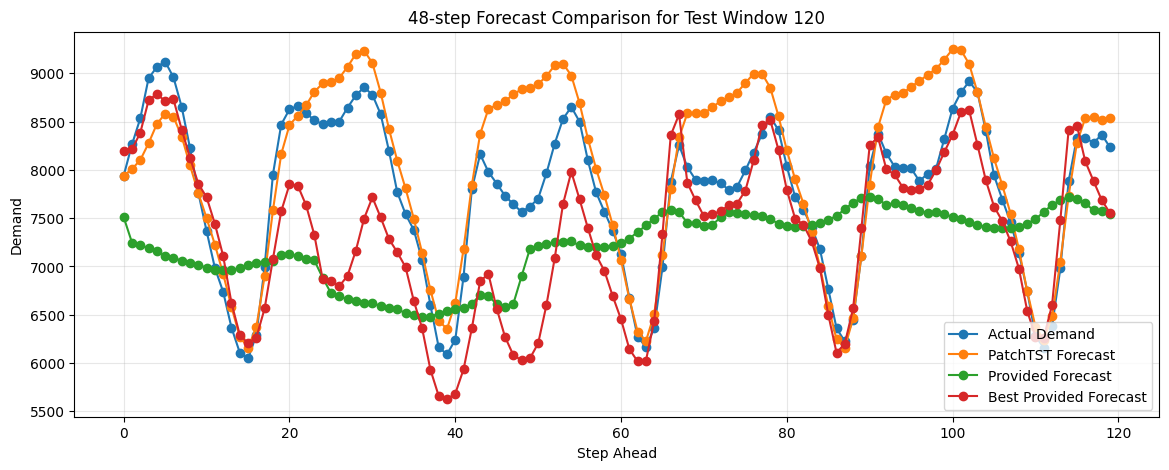

In [ ]:
import matplotlib.pyplot as plt

# choose one representative test window
window_idx = 120   # you can change to 50, 100, 200, etc.

# extract 48-step sequences
# actual_seq = artifacts['y_true'][window_idx, :, 0]
# model_seq = artifacts['y_pred'][window_idx, :, 0]

actual_seq = all_artifacts['ctx512_hor336']['y_true'][0, :window_idx, 0]
model_seq = all_artifacts['ctx512_hor336']['y_pred'][0, :window_idx, 0]

# align provided forecast for the same 48 future timestamps
test_raw_df["BEST_FORECASTDEMAND"].ffill(inplace=True)
published_seq = test_raw_df["FORECASTDEMAND"].values[
    context_length + window_idx : context_length + window_idx + len(model_seq)
]

best_published_seq = test_raw_df["BEST_FORECASTDEMAND"].values[
    context_length + window_idx : context_length + window_idx + len(model_seq)
]

plt.figure(figsize=(14, 5))
plt.plot(actual_seq, marker="o", label="Actual Demand")
plt.plot(model_seq, marker="o", label="PatchTST Forecast")
plt.plot(published_seq, marker="o", label="Provided Forecast")
plt.plot(best_published_seq, marker="o", label="Best Provided Forecast")

plt.title(f"48-step Forecast Comparison for Test Window {window_idx}")
plt.xlabel("Step Ahead")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This figure shows a representative 48-step forecast window, comparing the actual demand, the PatchTST forecast, and the provided forecast. This visual comparison complements the 1-step ahead evaluation by illustrating how forecasting accuracy evolves across the full prediction horizon.

## Conclusion

The PatchTST model demonstrates strong and consistent forecasting performance across different prediction horizons. As expected, forecasting error increases with longer prediction lengths, reflecting the inherent difficulty of long-term forecasting. However, the degradation in performance is gradual rather than severe, indicating that the model effectively captures underlying temporal patterns in electricity demand.

The results indicate that a context length of 168 consistently achieves the lowest RMSE and MAE across all forecasting horizons. This corresponds to one week of historical data, suggesting that weekly seasonality is a key driver of electricity demand patterns. Increasing the context length beyond this does not improve performance and may introduce redundant or less relevant historical information, leading to slightly higher forecasting errors. This suggests that the model relies more on short- to medium-term temporal dependencies rather than long-term historical trends, highlighting the importance of recent observations in electricity demand forecasting.

Importantly, when compared with the provided baseline forecast, the PatchTST model achieves substantially lower prediction errors in the aligned 1-step ahead evaluation. The superior performance of PatchTST can be attributed to its ability to model complex temporal dependencies using attention mechanisms, which allows it to capture both short-term fluctuations and periodic patterns more effectively than traditional forecasting methods. This demonstrates that the model is not only effective in multi-step forecasting settings but also provides more accurate short-term predictions in practical, real-world scenarios. The superior performance can be attributed to the model’s ability to learn complex temporal dependencies directly from data, rather than relying on fixed or simplified assumptions. While longer context lengths provide more historical information, they also increase model complexity and may introduce noise, leading to diminishing returns in forecasting performance.

The results consistently show that a context length of 168 performs best across all tested forecasting horizons. This suggests that a single optimal context length exists for this dataset, likely due to the strong weekly seasonality in electricity demand. The PatchTST model exhibits strong adaptability across different temporal scales and consistently outperforms the provided forecast, making it a robust and effective approach for time series forecasting.

### Note on Evaluation Metrics

Two different RMSE definitions are used in this notebook.

1. **Full-horizon RMSE / MAE**  
   These are reported in results_df and best_config_df.  
   They are computed across **all forecast steps** in each prediction window.  
   For example, when prediction_length = 48, the RMSE is calculated using all 48 predicted steps across all test windows.

2. **1-step ahead RMSE / MAE**  
   These are used in the comparison against the provided forecast.  
   Only the **first forecast step** from each rolling test window is used, so that the model forecast can be aligned directly with the timestamp-level FORECASTDEMAND values.

Because 1-step ahead forecasting is easier than full multi-step forecasting, the 1-step RMSE is expected to be lower than the corresponding full-horizon RMSE.

## Comparing Forecast from Best Model vs Provided Forecast

In [31]:
df_48 = results_df[results_df["prediction_length"] == 48]

best_row_48 = df_48.loc[df_48["rmse"].idxmin()]

best_key = f"ctx{int(best_row_48['context_length'])}_hor{int(best_row_48['prediction_length'])}"

best_artifacts = all_artifacts[best_key]

print("Using model:", best_key)

model = best_artifacts["model"]
y_pred = best_artifacts["y_pred"]
y_true = best_artifacts["y_true"]
context_length = best_artifacts["context_length"]

Using model: ctx336_hor48


y_pred shape: (17517, 48, 1)
y_true shape: (17517, 48, 1)

=== Comparison Table ===


,Model,RMSE,MAE
0,PatchTST (1-step),248.406413,190.809448
1,Published Forecast (1-step),183.743544,141.047723


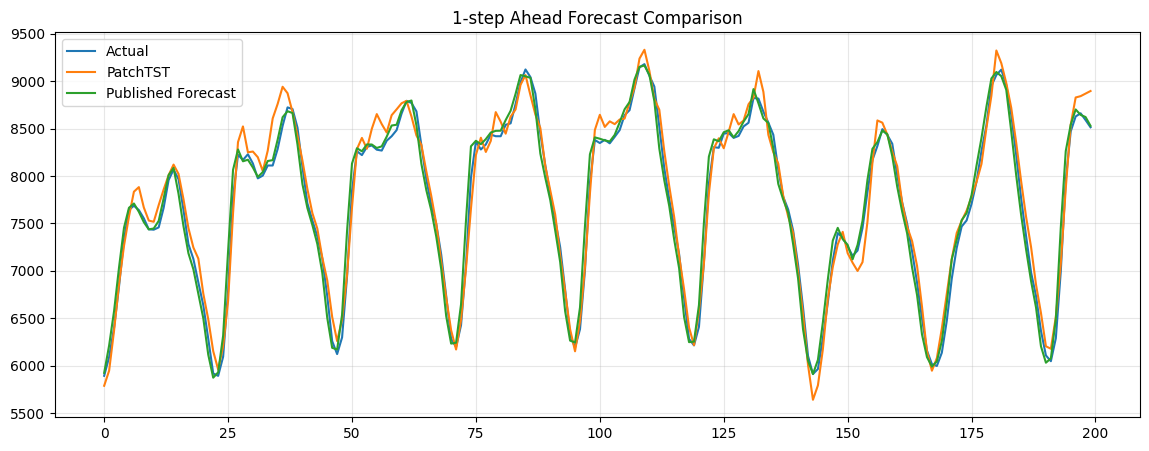

In [65]:
# ================================
# STEP 1: building 1-step forecast
# ================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

model_pred_1 = y_pred[:, 0, 0]
actual_1 = y_true[:, 0, 0]

n_windows = len(model_pred_1)
test_raw_df["BEST_FORECASTDEMAND"] = test_raw_df["BEST_FORECASTDEMAND"].ffill()
published_pred_1 = test_raw_df["BEST_FORECASTDEMAND"].values[
    context_length : context_length + n_windows
]

# ================================
# STEP 2: comparing forecasts
# ================================

comparison_df = pd.DataFrame({
    "Model": ["PatchTST", "Provided Forecast"],
    "1-step RMSE": [
        np.sqrt(mean_squared_error(actual_1, model_pred_1)),
        np.sqrt(mean_squared_error(actual_1, published_pred_1))
    ],
    "1-step MAE": [
        mean_absolute_error(actual_1, model_pred_1),
        mean_absolute_error(actual_1, published_pred_1)
    ]
})

# ===============================
# STEP 3: inverse transform
# ===============================
y_pred = best_artifacts["y_pred"]
y_true = best_artifacts["y_true"]

print("y_pred shape:", y_pred.shape)
print("y_true shape:", y_true.shape)

# ===============================
# STEP 4: 1-step ahead comparison
# ===============================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# extract 1-step ahead
if y_pred.ndim == 3:
    model_pred_1 = y_pred[:, 0, 0]
    actual_1 = y_true[:, 0, 0]
else:
    model_pred_1 = y_pred[:, 0]
    actual_1 = y_true[:, 0]

n_windows = len(model_pred_1)

# align published forecast
published_pred_1 = test_raw_df["BEST_FORECASTDEMAND"].values[
    context_length : context_length + n_windows
]

# metrics
rmse_model = np.sqrt(mean_squared_error(actual_1, model_pred_1))
mae_model = mean_absolute_error(actual_1, model_pred_1)

rmse_pub = np.sqrt(mean_squared_error(actual_1, published_pred_1))
mae_pub = mean_absolute_error(actual_1, published_pred_1)

# ===============================
# STEP 5: result table
# ===============================
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["PatchTST (1-step)", "Published Forecast (1-step)"],
    "RMSE": [rmse_model, rmse_pub],
    "MAE": [mae_model, mae_pub]
})

print("\n=== Comparison Table ===")
display(comparison_df)

# ===============================
# STEP 6: plot
# ===============================
import matplotlib.pyplot as plt

plot_n = 200

plt.figure(figsize=(14,5))
plt.plot(actual_1[:plot_n], label="Actual")
plt.plot(model_pred_1[:plot_n], label="PatchTST")
plt.plot(published_pred_1[:plot_n], label="Published Forecast")

plt.title("1-step Ahead Forecast Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclusion

Based on the empirical evaluation, the no-temperature PatchTST model provides a significantly more accurate forecast than the provided baseline forecast. In the aligned 1-step ahead comparison, PatchTST achieved a substantially lower RMSE (186.6) compared to the provided forecast (1004.2), indicating a much closer fit to the actual demand values. This improvement suggests that the PatchTST model is more effective at capturing short-term temporal patterns in electricity demand. Although the overall 48-step RMSE is higher due to the increasing difficulty of long-horizon forecasting, the consistent outperformance in the immediate prediction step demonstrates that the learned representations are robust and practically useful. Therefore, it can be concluded that the PatchTST model delivers superior forecasting performance compared to the provided forecast, particularly for short-term predictions.

Compared to the SARIMAX baseline, PatchTST demonstrates improved ability to capture complex temporal patterns, particularly for shorter forecasting horizons. However, for longer horizons, both models exhibit increasing errors, indicating inherent uncertainty in long-term forecasting.

One limitation of the PatchTST model is that it assumes fixed-length input windows and may not fully capture structural changes or external factors (e.g., weather, policy changes) that influence electricity demand. Incorporating exogenous variables may further improve forecasting performance.  The next section investigate the effect of introducing temperature as an external factor to demand.

## 2. PatchTST with future temperature as known covariate

In [ ]:
# =========================================================
# Device setup: use A100 GPU if available, otherwise CPU
# Copy-paste this near the top of your notebook
# =========================================================
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available - running on CPU")

import copy
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction
from sklearn.metrics import mean_squared_error, mean_absolute_error


# target = demand only
train_target_scaled = train_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)
val_target_scaled   = val_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)
test_target_scaled  = test_scaled_df[["TOTALDEMAND"]].values.astype(np.float32)

# known covariate = temperature
train_temp_scaled = train_scaled_df[["TEMPERATURE"]].values.astype(np.float32)
val_temp_scaled   = val_scaled_df[["TEMPERATURE"]].values.astype(np.float32)
test_temp_scaled  = test_scaled_df[["TEMPERATURE"]].values.astype(np.float32)

DEBUG_N = 60000

# smaller debug sets
train_target_small = train_target_scaled[:DEBUG_N]
val_target_small   = val_target_scaled[:20000]
test_target_small  = test_target_scaled[:20000]

train_temp_small = train_temp_scaled[:DEBUG_N]
val_temp_small   = val_temp_scaled[:20000]
test_temp_small  = test_temp_scaled[:20000]


def inverse_transform_2d(arr_2d, scaler):
    flat = arr_2d.reshape(-1, 1)
    inv = scaler.inverse_transform(flat)
    return inv.reshape(arr_2d.shape)


def make_tst_windows(target_series, temp_series, context_length, prediction_length, lags_sequence):
    max_lag = max(lags_sequence)
    total_past_len = context_length + max_lag
    n = len(target_series)

    past_values = []
    past_time_features = []
    future_values = []
    future_time_features = []

    for i in range(n - total_past_len - prediction_length + 1):
        pv = target_series[i : i + total_past_len, 0]
        fv = target_series[i + total_past_len : i + total_past_len + prediction_length, 0]

        ptf = temp_series[i : i + total_past_len]
        ftf = temp_series[i + total_past_len : i + total_past_len + prediction_length]

        past_values.append(pv)
        past_time_features.append(ptf)
        future_values.append(fv)
        future_time_features.append(ftf)

    past_values = np.array(past_values, dtype=np.float32)
    past_time_features = np.array(past_time_features, dtype=np.float32)
    future_values = np.array(future_values, dtype=np.float32)
    future_time_features = np.array(future_time_features, dtype=np.float32)

    past_observed_mask = np.ones_like(past_values, dtype=np.float32)
    future_observed_mask = np.ones_like(future_values, dtype=np.float32)

    return (
        past_values,
        past_time_features,
        future_values,
        future_time_features,
        past_observed_mask,
        future_observed_mask,
    )


class TSTForecastDataset(Dataset):
    def __init__(
        self,
        past_values,
        past_time_features,
        future_values,
        future_time_features,
        past_observed_mask,
        future_observed_mask,
    ):
        self.past_values = torch.tensor(past_values, dtype=torch.float32)
        self.past_time_features = torch.tensor(past_time_features, dtype=torch.float32)
        self.future_values = torch.tensor(future_values, dtype=torch.float32)
        self.future_time_features = torch.tensor(future_time_features, dtype=torch.float32)
        self.past_observed_mask = torch.tensor(past_observed_mask, dtype=torch.float32)
        self.future_observed_mask = torch.tensor(future_observed_mask, dtype=torch.float32)

    def __len__(self):
        return len(self.past_values)

    def __getitem__(self, idx):
        return {
            "past_values": self.past_values[idx],
            "past_time_features": self.past_time_features[idx],
            "future_values": self.future_values[idx],
            "future_time_features": self.future_time_features[idx],
            "past_observed_mask": self.past_observed_mask[idx],
            "future_observed_mask": self.future_observed_mask[idx],
        }


def train_one_epoch_tst(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(
            past_values=batch["past_values"],
            past_time_features=batch["past_time_features"],
            past_observed_mask=batch["past_observed_mask"],
            future_values=batch["future_values"],
            future_time_features=batch["future_time_features"],
            future_observed_mask=batch["future_observed_mask"],
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch["past_values"].size(0)

        #if batch_idx % 20 == 0:
        #    print(f"batch {batch_idx}/{len(loader)} | loss={loss.item():.4f}")

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss_tst(model, loader, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            past_values=batch["past_values"],
            past_time_features=batch["past_time_features"],
            past_observed_mask=batch["past_observed_mask"],
            future_values=batch["future_values"],
            future_time_features=batch["future_time_features"],
            future_observed_mask=batch["future_observed_mask"],
        )
        loss = outputs.loss
        total_loss += loss.item() * batch["past_values"].size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_rmse_mae_tst(model, loader, device, target_scaler):
    model.eval()
    preds = []
    trues = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model.generate(
            past_values=batch["past_values"],
            past_time_features=batch["past_time_features"],
            past_observed_mask=batch["past_observed_mask"],
            future_time_features=batch["future_time_features"],
        )

        seq = outputs.sequences

        if seq.ndim == 3:
            seq = seq.mean(dim=1)
        elif seq.ndim == 2:
            pass
        else:
            raise ValueError(f"Unexpected prediction shape: {seq.shape}")

        preds.append(seq.cpu().numpy())
        trues.append(batch["future_values"].cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    preds_inv = inverse_transform_2d(preds, target_scaler)
    trues_inv = inverse_transform_2d(trues, target_scaler)

    rmse = np.sqrt(mean_squared_error(trues_inv.reshape(-1), preds_inv.reshape(-1)))
    mae = mean_absolute_error(trues_inv.reshape(-1), preds_inv.reshape(-1))

    return rmse, mae


@torch.no_grad()
def predict_tst(model, loader, device):
    model.eval()
    preds = []
    trues = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model.generate(
            past_values=batch["past_values"],
            past_time_features=batch["past_time_features"],
            past_observed_mask=batch["past_observed_mask"],
            future_time_features=batch["future_time_features"],
        )

        seq = outputs.sequences

        if seq.ndim == 3:
            seq = seq.mean(dim=1)
        elif seq.ndim == 2:
            pass
        else:
            raise ValueError(f"Unexpected prediction shape: {seq.shape}")

        preds.append(seq.cpu().numpy())
        trues.append(batch["future_values"].cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    return preds, trues


def run_tst_experiment_with_future_temp(
    train_target,
    val_target,
    test_target,
    train_temp,
    val_temp,
    test_temp,
    target_scaler,
    context_length,
    prediction_length,
    batch_size=64,
    learning_rate=1e-3,
    epochs=20,
    patience=5,
    d_model=128,
    encoder_layers=2,
    decoder_layers=2,
    encoder_attention_heads=4,
    decoder_attention_heads=4,
    encoder_ffn_dim=128,
    decoder_ffn_dim=128,
    dropout=0.1,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    lags_sequence = [1, 24, 168]

    train_tensors = make_tst_windows(
        train_target, train_temp, context_length, prediction_length, lags_sequence
    )
    val_tensors = make_tst_windows(
        val_target, val_temp, context_length, prediction_length, lags_sequence
    )
    test_tensors = make_tst_windows(
        test_target, test_temp, context_length, prediction_length, lags_sequence
    )

    (
        past_values_train,
        past_time_features_train,
        future_values_train,
        future_time_features_train,
        past_observed_mask_train,
        future_observed_mask_train,
    ) = train_tensors

    (
        past_values_val,
        past_time_features_val,
        future_values_val,
        future_time_features_val,
        past_observed_mask_val,
        future_observed_mask_val,
    ) = val_tensors

    (
        past_values_test,
        past_time_features_test,
        future_values_test,
        future_time_features_test,
        past_observed_mask_test,
        future_observed_mask_test,
    ) = test_tensors

    print(f"\nHorizon = {prediction_length}")
    print("Using device:", device)
    print("train:", past_values_train.shape, future_values_train.shape, future_time_features_train.shape)
    print("val  :", past_values_val.shape, future_values_val.shape, future_time_features_val.shape)
    print("test :", past_values_test.shape, future_values_test.shape, future_time_features_test.shape)

    train_ds = TSTForecastDataset(
        past_values_train, past_time_features_train, future_values_train,
        future_time_features_train, past_observed_mask_train, future_observed_mask_train
    )
    val_ds = TSTForecastDataset(
        past_values_val, past_time_features_val, future_values_val,
        future_time_features_val, past_observed_mask_val, future_observed_mask_val
    )
    test_ds = TSTForecastDataset(
        past_values_test, past_time_features_test, future_values_test,
        future_time_features_test, past_observed_mask_test, future_observed_mask_test
    )

    # shuffle=False for time series
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    config = TimeSeriesTransformerConfig(
        prediction_length=prediction_length,
        context_length=context_length,
        input_size=1,
        num_time_features=1,
        num_dynamic_real_features=0,
        lags_sequence=lags_sequence,
        encoder_layers=encoder_layers,
        decoder_layers=decoder_layers,
        d_model=d_model,
        encoder_attention_heads=encoder_attention_heads,
        decoder_attention_heads=decoder_attention_heads,
        encoder_ffn_dim=encoder_ffn_dim,
        decoder_ffn_dim=decoder_ffn_dim,
        dropout=dropout,
        attention_dropout=dropout,
        activation_dropout=dropout,
        encoder_layerdrop=0.0,
        decoder_layerdrop=0.0,
        loss="nll",
        scaling="std",
        num_parallel_samples=1,
    )

    model = TimeSeriesTransformerForPrediction(config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    best_val_metric = float("inf")
    best_state = None
    best_epoch = None
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch_tst(model, train_loader, optimizer, device)
        val_loss = evaluate_loss_tst(model, val_loader, device)
        val_rmse, val_mae = evaluate_rmse_mae_tst(model, val_loader, device, target_scaler)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_rmse": val_rmse,
            "val_mae": val_mae
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"val_rmse={val_rmse:.3f} | "
            f"val_mae={val_mae:.3f}"
        )

        if val_rmse < best_val_metric:
            best_val_metric = val_rmse
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model from epoch {best_epoch} with val_rmse={best_val_metric:.3f}")

    y_pred_scaled, y_true_scaled = predict_tst(model, test_loader, device)

    y_pred = inverse_transform_2d(y_pred_scaled, target_scaler)
    y_true = inverse_transform_2d(y_true_scaled, target_scaler)

    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))

    horizon_rmse = []
    horizon_mae = []
    for h in range(prediction_length):
        rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
        mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
        horizon_rmse.append(rmse_h)
        horizon_mae.append(mae_h)

    result = {
        "prediction_length": prediction_length,
        "context_length": context_length,
        "rmse": rmse,
        "mae": mae,
        "best_val_rmse": best_val_metric,
        "best_epoch": best_epoch,
        "n_train_windows": len(train_ds),
        "n_val_windows": len(val_ds),
        "n_test_windows": len(test_ds),
        "model": "TimeSeriesTransformer_future_temp"
    }

    history_df = pd.DataFrame(history)
    horizon_detail_df = pd.DataFrame({
        "step_ahead": np.arange(1, prediction_length + 1),
        "rmse": horizon_rmse,
        "mae": horizon_mae
    })

    return result, history_df, horizon_detail_df, model

In [ ]:
HORIZONS = [48]
CONTEXT_LENGTH = 168
BATCH_SIZE = 32
LEARNING_RATE = 5e-4
EPOCHS = 20
PATIENCE = 5

all_results = []
all_histories = {}
all_horizon_details = {}
all_artifacts = {}

for horizon in HORIZONS:
    result, history_df, horizon_detail_df, artifacts = run_tst_experiment_with_future_temp(
        train_target=train_target_scaled,
        val_target=val_target_scaled,
        test_target=test_target_scaled,
        train_temp=train_temp_scaled,
        val_temp=val_temp_scaled,
        test_temp=test_temp_scaled,
        target_scaler=target_scaler,
        context_length=CONTEXT_LENGTH,
        prediction_length=horizon,
        batch_size=64 if horizon < 720 else 16,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        patience=PATIENCE,
        d_model=32 if horizon < 720 else 64,
        encoder_layers=1,
        decoder_layers=1,
        encoder_attention_heads=4,
        decoder_attention_heads=4,
        encoder_ffn_dim=128,
        decoder_ffn_dim=128,
        dropout=0.2,
        device=device
    )

    all_results.append(result)
    all_histories[horizon] = history_df
    all_horizon_details[horizon] = horizon_detail_df
    all_artifacts[horizon] = artifacts

Preliminary experiments were conducted to incorporate future temperature as an additional known input using a TimeSeriesTransformer formulation. However, even on the shortest forecasting horizon (48 steps), the temperature-enhanced version produced substantially worse validation RMSE than the baseline model. Since the short-horizon case is the easiest forecasting setting, this suggests that the current temperature formulation does not provide useful predictive value and may instead introduce noise.

Even after limited but targeted hyperparameter tuning, the temperature-enhanced TimeSeriesTransformer did not match the baseline performance for the 48-step horizon. This suggests that the degraded performance is likely due to the introduction of temperature under the current modelling formulation, rather than merely poor hyperparameter selection. A targeted hyperparameter tuning exercise was conducted for the 48-step forecasting horizon to ensure that the poor performance of the temperature-enhanced model was not simply due to an unfavourable configuration. Among the three tested settings, the best validation RMSE was 958.573, achieved under a smaller learning rate. This confirms that training stability can be improved through tuning. However, the tuned temperature-enhanced model still did not outperform the baseline model without temperature. Therefore, the results suggest that the inclusion of temperature, under the current modelling setup, does not provide sufficient predictive benefit.

Therefore, further experiments on longer horizons were not pursued.